In [7]:
import sys
sys.path.append("..")
import numpy as np
import torch

import matplotlib.pyplot as plt
from Datasets import matconv as mc
from prog import mlps, trainer, featlib, hlprs

In [2]:
# Data generation settings
noise=0.0
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

In [8]:
# Dataset building
device = 'cpu'
partitions = mc.build_dataset_from_burgers(noise_level=noise, nu=nu, stride_t=stride_t, stride_x=stride_x, seed=seed, quantile_splits=part_num, return_partitions=True)
t_np, x_np, y_np, y_noisy_np, N = partitions[[k for k in partitions if k.startswith(f'Q{which_part}:')][0]]
# batches are generated over t_np, x_np, y_np, y_noisy_np

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_torch       = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

In [9]:
selected_derivs=('u','u_x','u_xx') # up to first order derivative inputs
lr=0.001
batch_size=1000  # number of data points used on optimization step 
                 # data points are generated according to tensor.randint over spacetime mesh
lam_pde=0.0
lam_reg=0.0
lam_tv=0.0
lam_data=10.0

#output settings
log_every=1000

In [10]:
# Initializing u_model and a dummy v_model so that trainer works
u_model=mlps.SimpleMLP(n_layers=4,hidden_size=64)
v_model=mlps.EQL(in_dim=len(selected_derivs), prod_dim=0, bias=False) # dummy v_model for working code
for param in v_model.parameters(): #freeze v_model params
    param.requires_grad = False
print('v model parameters (weights) are not receiving gradients (improve data fit accuracy)')

train_config=trainer.TrainerConfig(
    lr=lr,
    lambda_pde=lam_pde, 
    lambda_reg=lam_reg,
    lambda_tv=lam_tv, 
    lambda_data=lam_data, 
    selected_derivs=selected_derivs, 
)
ft = featlib.FeatureTensor(selected_derivs, normalize=False)
feature_builder = ft.build
train=trainer.PDETrainer(u_model=u_model,v_model=v_model,cfg=train_config, feature_builder=feature_builder)
'rmrfjk'

v model parameters (weights) are not receiving gradients (improve data fit accuracy)


C:\Users\sami\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


'rmrfjk'

In [15]:
for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    if i%log_every==0:
        print(f'step {i} data_loss={ld} pde_loss={lp}')

step 0 data_loss=0.00022784556495025754 pde_loss=0.5599415302276611
step 1000 data_loss=0.0001667844771873206 pde_loss=0.6661416292190552
step 2000 data_loss=6.277512875385582e-05 pde_loss=0.7031010389328003
step 3000 data_loss=4.986020576325245e-05 pde_loss=0.5534226298332214


Max difference at index: 32
ux_fd[32] = -6.208283548742757
ux_agclip[32] = -4.588348388671875
Max diff occurs at x=0.7853981852531433


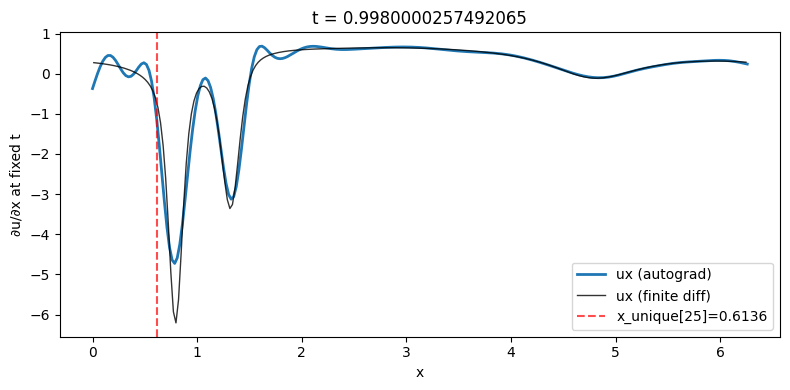

In [16]:
### DIFF TESTS ###  
# --- 1) Build sorted unique axes ---
t_unique = np.unique(t_np)
x_unique = np.unique(x_np)
Nt, Nx = len(t_unique), len(x_unique)

# --- 2) Map flattened samples into a (Nt, Nx) grid ---
# This is robust to ordering: we place each (t,x) into its index.
t_to_i = {v: i for i, v in enumerate(t_unique)}
x_to_j = {v: j for j, v in enumerate(x_unique)}

U = np.empty((Nt, Nx), dtype=np.float64)
U[:] = np.nan

for tt, xx, yy in zip(t_np, x_np, y_np):
    U[t_to_i[tt], x_to_j[xx]] = yy


# --- 3) Choose a time slice k ---
k = Nt-2             # middle time, change as you like
t0 = t_unique[k]
u_row = U[k, :]           # u(t0, x_j)

# --- 4) Finite difference du/dx along x on that slice ---
dx = np.diff(x_unique) 
du = np.diff(u_row)
ux_fd = du / dx
x_mid = 0.5 * (x_unique[1:] + x_unique[:-1])  # centers for plotting FD

# --- 5) Autograd du/dx on the same slice ---
x_t = torch.tensor(x_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)
t_t = torch.full_like(x_t, float(t0))  # same t0 for all x

u_out = train.u(t_t, x_t)         # (Nx, 1)
ux_ag = torch.autograd.grad(
    u_out, x_t,
    grad_outputs=torch.ones_like(u_out),
    create_graph=False,
    retain_graph=False
)[0].detach().cpu().numpy().ravel()

ux_agclip=ux_ag[1:]
np.linalg.norm(ux_fd-ux_agclip, ord=np.inf),max(ux_fd-ux_agclip)
max_diff_idx = np.argmax(np.abs(ux_fd - ux_agclip))
print(f"Max difference at index: {max_diff_idx}")
print(f"ux_fd[{max_diff_idx}] = {ux_fd[max_diff_idx]}")
print(f"ux_agclip[{max_diff_idx}] = {ux_agclip[max_diff_idx]}")
print(f"Max diff occurs at x={x_unique[max_diff_idx]}")

# --- 6) Plot (note: FD is length Nx-1, autograd is length Nx) ---
plt.figure(figsize=(8,4))
plt.plot(x_unique, ux_ag, label='ux (autograd)', linewidth=2)
plt.plot(x_mid, ux_fd, label='ux (finite diff)', linewidth=1, alpha=0.8, color='black')
plt.axvline(x=x_unique[25], color='red', linestyle='--', alpha=0.7, label=f'x_unique[25]={x_unique[25]:.4f}')
plt.xlabel('x')
plt.ylabel('∂u/∂x at fixed t')
plt.title(f"t = {t0}")
plt.legend()
plt.tight_layout()
plt.show()



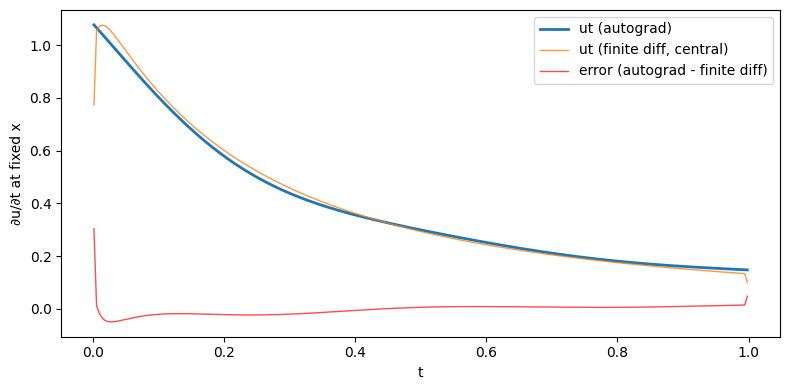

rel L2: 0.05524094333378735
Linf : 0.303850151067695


In [17]:
def grad1(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

# pick a fixed x0 (one of your grid x values)
x0 = float(x_unique[Nx // 2])  # middle x; or choose any

t_t = torch.tensor(t_unique, dtype=torch.float32, device=device, requires_grad=True).unsqueeze(1)  # (Nt,1)
x_t = torch.full_like(t_t, x0)  # same x0 for all t

u_out = train.u(t_t, x_t)  # (Nt,1)
ut = grad1(u_out, t_t)          # (Nt,1)

ut_np = ut.detach().cpu().numpy().ravel()

# index for x0
j0 = np.where(x_unique == x0)[0][0]

u_tseries = U[:, j0]        # shape (Nt,)
dt = np.diff(t_unique)

ut_fd = np.diff(u_tseries) / dt               # forward (length Nt-1)
t_mid = 0.5 * (t_unique[1:] + t_unique[:-1])  # for plotting

dt0 = t_unique[1] - t_unique[0]
ut_fd_central = (u_tseries[2:] - u_tseries[:-2]) / (4*dt0)  # length Nt-2
t_center = t_unique[1:-1]

ut_ag_trim = ut_np[1:-1]
err = ut_ag_trim - ut_fd_central

plt.figure(figsize=(8,4))
plt.plot(t_center, ut_ag_trim, label="ut (autograd)", linewidth=2)
plt.plot(t_center, ut_fd_central, label="ut (finite diff, central)", linewidth=1, alpha=0.8)
plt.plot(t_center, err, label="error (autograd - finite diff)", linewidth=1, alpha=0.7, color='red')
plt.xlabel("t")
plt.ylabel("∂u/∂t at fixed x")
plt.legend()
plt.tight_layout()
plt.show()

print("rel L2:", np.linalg.norm(err)/np.linalg.norm(ut_ag_trim))
print("Linf :", np.linalg.norm(err, np.inf))

Now we try symnet tests

In [18]:
symnet = mlps.EQL(in_dim=3, prod_dim=2, bias=False)
symnet.linear.weight

Parameter containing:
tensor([[ 0.3298, -0.3984,  0.3267],
        [ 0.2305, -0.4360, -0.1834]], requires_grad=True)

In [19]:
train.v = symnet # swap out v_model for symnet
print(train.v.linear.weight) # verify weights are hardcoded
params = list(train.u.parameters()) + list(train.v.parameters())
train.optimizer = torch.optim.Adam(params, lr=lr) # update optimizer to replace dummy v model with symnet weights


Parameter containing:
tensor([[ 0.3298, -0.3984,  0.3267],
        [ 0.2305, -0.4360, -0.1834]], requires_grad=True)


In [21]:
#Sanity check: set loss to L_p, and freeze the data fit while training only symnet

train_config.lambda_data = 0.0
train_config.lambda_pde = 10.0
for params in u_model.parameters(): 
    params.requires_grad = False

for params in symnet.parameters(): 
    params.requires_grad = True

In [22]:
plot_pde_ls = []

for i in range(4000): 
    t,x,u_noisy,u_clean = hlprs.make_nonlinear_batch(batch_size=batch_size,t_torch=t_torch,x_torch=x_torch,y_torch=y_noisy_torch)
    out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean)
    ld = out['loss_data']
    lp = out['loss_pde']
    plot_pde_ls.append(lp)
    if i%log_every==0:
        print(f'step_{i}, data_loss={ld}, pde_loss={lp}')

step_0, data_loss=3.835195457213558e-05, pde_loss=1.0334362983703613
step_1000, data_loss=3.5473254683893174e-05, pde_loss=0.023179518058896065
step_2000, data_loss=3.0166696888045408e-05, pde_loss=0.0031420253217220306
step_3000, data_loss=4.507434641709551e-05, pde_loss=0.0032524915877729654


In [23]:
print(list(train.v.parameters()))

[Parameter containing:
tensor([[ 1.6163,  0.0042,  0.0189],
        [-0.0177, -1.2816, -0.0135]], requires_grad=True), Parameter containing:
tensor([[-0.0312,  0.0051, -0.0013,  0.4769]], requires_grad=True)]


We can do algebra to get coefficient values: 